In [19]:
import matplotlib 
import pandas as pd

output: pd.DataFrame = pd.read_csv('../outputs/siamese_train_669423/val_triplets_predictions.csv')

In [20]:
output.head(0)

,anchor_path,pos_path,neg_path,d_ap,d_an,delta


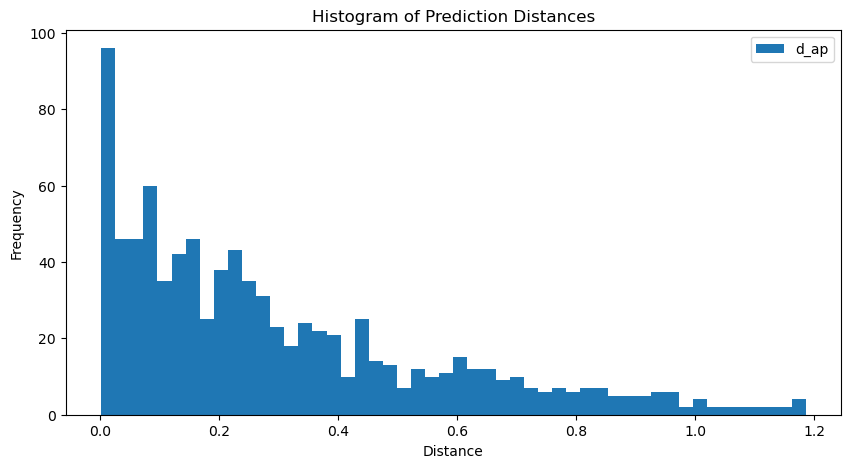

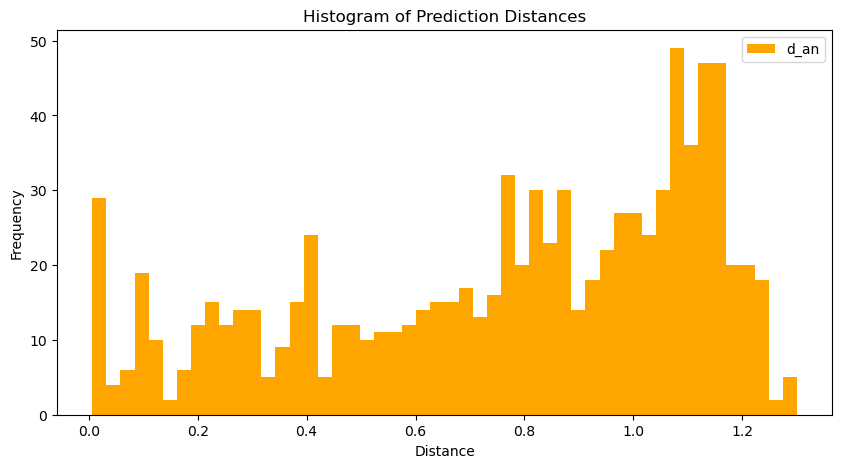

In [21]:
# plot histogram of the prediction scores in two different figures
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.hist(output['d_ap'], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction Distances')
plt.legend(['d_ap', 'd_an'])
plt.show()

plt.figure(figsize=(10,5))
plt.hist(output['d_an'], bins=50, color='orange')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction Distances')
plt.legend(['d_an'])
plt.show()

In [38]:
# add a column specifying if the score is relevant or not 
# for d_ap, relevant if distance < 0.5
# for d_an, relevant if distance > 0.5
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import numpy as np
true_labels = np.concatenate((np.ones(len(output)), np.zeros(len(output))))
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
        prediction = np.concatenate(((output['d_ap'].values < threshold).astype(int), (1 - (output['d_an'].values > threshold)).astype(int)))
        accuracy = accuracy_score(true_labels, prediction)
        precision = precision_score(true_labels, prediction)
        recall = recall_score(true_labels, prediction)
        f1 = f1_score(true_labels, prediction)
        print(f'Threshold {threshold}: Overall - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}')


Threshold 0.3: Overall - Accuracy: 0.7350, Precision: 0.8043, Recall: 0.6211, F1-score: 0.7009
Threshold 0.4: Overall - Accuracy: 0.7583, Precision: 0.7805, Recall: 0.7189, F1-score: 0.7484
Threshold 0.5: Overall - Accuracy: 0.7717, Precision: 0.7604, Recall: 0.7933, F1-score: 0.7765
Threshold 0.6: Overall - Accuracy: 0.7722, Precision: 0.7393, Recall: 0.8411, F1-score: 0.7869
Threshold 0.7: Overall - Accuracy: 0.7644, Precision: 0.7106, Recall: 0.8922, F1-score: 0.7911


Overall - Accuracy: 0.7583, Precision: 0.7805, Recall: 0.7189, F1-score: 0.7484
